<a href="https://colab.research.google.com/github/bongjunpyo/SKIN_CANCER_ISIC/blob/main/Skin_Cancer_ISIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Cancer ISIC — 9클래스 피부 병변 분류

**데이터셋**: [Skin Cancer ISIC (9 classes)](https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic) — Train 2,239장 / Test 118장, 9개 병변 클래스.

**목표**: 피부 병변 이미지를 9개 클래스로 분류하는 모델을 단계적으로 개선한다.

| 단계 | 방법 | 핵심 아이디어 |
|---|---|---|
| 1 | 베이스라인 CNN | Conv 3블록 + Dropout, 밑바닥부터 학습 |
| 2 | 전이학습 (동결) | ImageNet 사전학습 EfficientNetB0, 특징추출기 동결 |
| 3 | Fine-tuning | 상위 블록만 해제, 낮은 학습률(1e-5)로 미세조정 |
| 4 | Test 평가 | 최종 모델을 hold-out Test 셋(118장)으로 평가 |

> 이 노트북은 위→아래로 순서대로 실행하도록 구성했다. 현재 출력은 로컬 CPU(TF 2.21) 전체 실행분(약 26분). Colab GPU 런타임에서도 동일하게 실행된다.

## 1. 데이터 준비

kagglehub로 데이터셋을 내려받는다(공개 데이터셋이라 별도 인증 불필요). 이후 `image_dataset_from_directory`로
Train 디렉토리를 80/20으로 나눠 train/validation 셋을 만든다 (180×180, batch 32, seed 123).

- 로드된 픽셀값은 **0–255 float 그대로** 유지한다 — 스케일링은 각 모델 내부에서 처리한다(아래 "입력 스케일 정책" 참고).

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

print("Path to dataset files:", path)

/private/tmp/claude-501/-Users-bongjunpyo/e504148e-92fd-4e3b-85bd-367e1bd0d448/scratchpad/tf-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0.00/786M [00:00<?, ?B/s]

  0%|          | 1.00M/786M [00:00<05:13, 2.62MB/s]

  0%|          | 2.00M/786M [00:00<03:06, 4.40MB/s]

  1%|          | 4.00M/786M [00:00<01:39, 8.25MB/s]

...

 99%|█████████▉| 780M/786M [00:36<00:00, 29.8MB/s]

100%|█████████▉| 784M/786M [00:36<00:00, 30.3MB/s]

100%|██████████| 786M/786M [00:36<00:00, 22.7MB/s]

Extracting files...


Path to dataset files: /Users/bongjunpyo/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1


In [2]:
import pathlib

# The 'path' variable contains the base directory of the downloaded dataset
# Using the directory structure observed from the previous cell's output
data_dir_base = pathlib.Path(path) / "Skin cancer ISIC The International Skin Imaging Collaboration"
data_dir_train = data_dir_base / "Train"
data_dir_test = data_dir_base / "Test"

print(f"Train data directory: {data_dir_train}")
print(f"Test data directory: {data_dir_test}")

Train data directory: /Users/bongjunpyo/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train
Test data directory: /Users/bongjunpyo/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Test


In [3]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2239
118


In [4]:
import random

batch_size = 32
img_height = 180
img_width = 180
rnd_seed = 123
random.seed(rnd_seed)

In [5]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.


Using 1792 files for training.


In [6]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.


Using 447 files for validation.


In [7]:
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


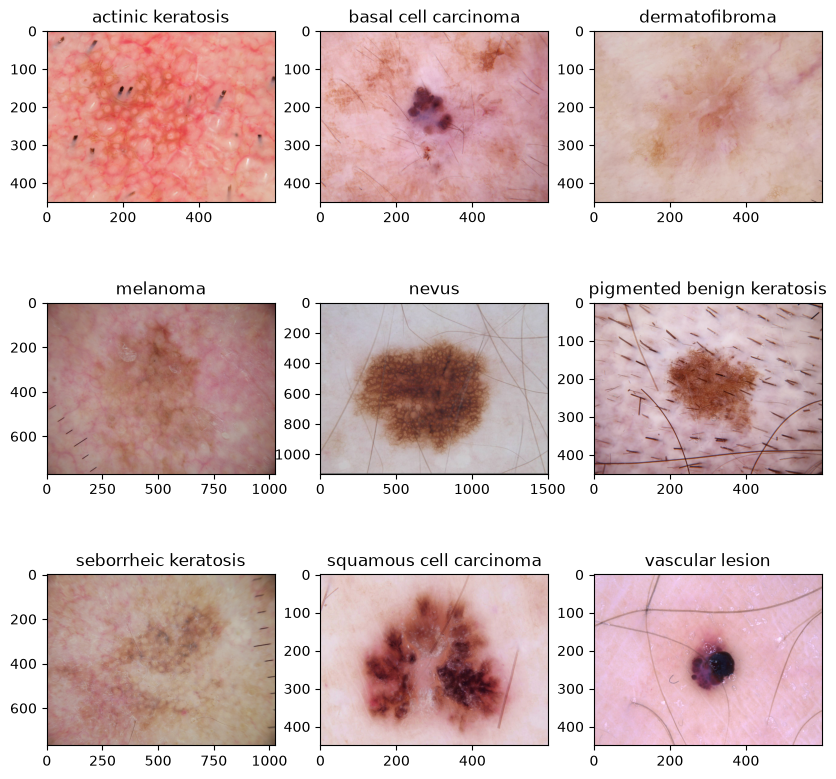

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as img

num_classes = len(class_names)
plt.figure(figsize=(10,10))
for i in range(num_classes):
  plt.subplot(3,3,i+1)
  image = img.imread(str(list(data_dir_train.glob(class_names[i]+'/*.jpg'))[1]))
  plt.title(class_names[i])
  plt.imshow(image)

In [9]:
for image_batch, labels_batch in train_ds.take(1):
    print(image_batch.shape)
    print(labels_batch.shape)

(32, 180, 180, 3)
(32,)


In [10]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 2. 베이스라인 CNN

**가설**: 작은 CNN(Conv 3블록)으로도 병변의 색·질감 특징을 일부 학습할 수 있지만, 학습 데이터가 2,239장뿐이라 밑바닥 학습은 일반화에 한계가 있을 것이다.

**실험**: Conv(16→32→64) + MaxPooling + Dropout 구조, Adam(lr=0.001), 25 epochs.

**입력 스케일 정책**: 이 모델은 첫 층에 `Rescaling(1./255)`을 포함하므로 **0–255 원본 입력**을 받아 모델 내부에서 0–1로 정규화한다.

In [11]:
model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.5),
  # Final layer without activation outputs logits
  tf.keras.layers.Dense(num_classes)
])

model.compile(
  optimizer='adam',
  # Use from_logits=True for better numerical stability
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

model.summary()

/private/tmp/claude-501/-Users-bongjunpyo/e504148e-92fd-4e3b-85bd-367e1bd0d448/scratchpad/tf-venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,801 (15.22 MB)

 Trainable params: 3,989,801 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# 'lr' was changed to 'learning_rate' in recent Keras versions
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss=SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [13]:
epochs = 25
history_baseline = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/25


/private/tmp/claude-501/-Users-bongjunpyo/e504148e-92fd-4e3b-85bd-367e1bd0d448/scratchpad/tf-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 1/56 ━━━━━━━━━━━━━━━━━━━━ 2:56 3s/step - accuracy: 0.1250 - loss: 2.2782

 2/56 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.1719 - loss: 3.4820

 3/56 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.2292 - loss: 3.6427

...

53/56 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.6138 - loss: 1.0500

54/56 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.6123 - loss: 1.0511

55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.6136 - loss: 1.0488

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.6138 - loss: 1.0516

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.6138 - loss: 1.0516 - val_accuracy: 0.5235 - val_loss: 1.3235


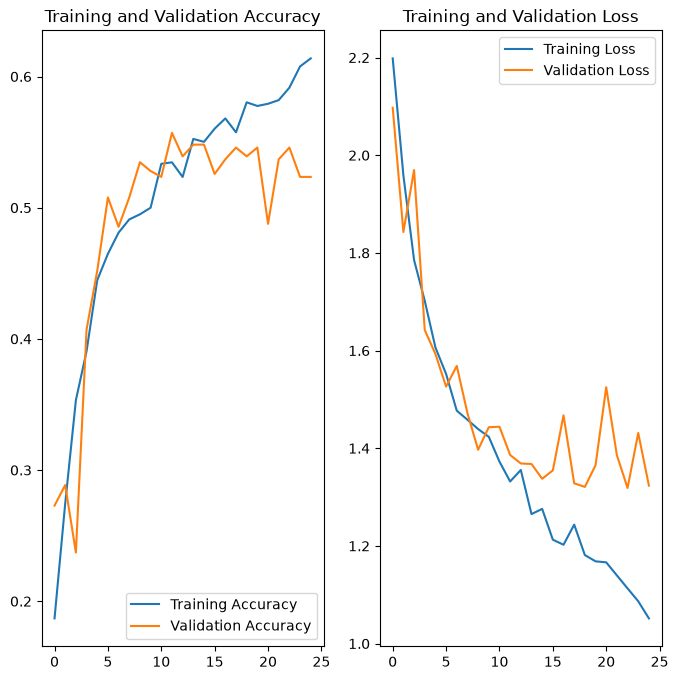

In [14]:
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']

loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**결과**: best val accuracy 0.557, 최종 epoch 0.524 — epoch 간 진동이 크고 train accuracy(~0.58)에 비해 불안정하다.

**결론**: 데이터가 적어 밑바닥 학습만으로는 한계가 뚜렷하다 → 사전학습 모델 전이학습으로 전환한다.

## 3. 전이학습 — EfficientNetB0 (특징추출기 동결)

**가설**: ImageNet에서 학습된 특징추출기를 재사용하면 같은 데이터로도 베이스라인을 넘을 것이다.

**실험**: `EfficientNetB0(include_top=False)` 동결 + GlobalAveragePooling + Dropout(0.5) + Dense(softmax), Adam(lr=0.001), 25 epochs.

### ⚠️ 입력 스케일 정책 — 베이스라인과 다름

| 모델 | 파이프라인이 공급하는 입력 | 정규화 위치 |
|---|---|---|
| 베이스라인 CNN | 0–255 | 모델 내부 `Rescaling(1./255)` 층 |
| EfficientNetB0 | **0–255 원본 그대로** | **모델 내장** — `keras.applications.EfficientNet` 계열은 전처리(스케일링·정규화)가 아키텍처 안에 포함됨 |

두 모델 모두 데이터 파이프라인에서는 0–255를 그대로 공급한다. EfficientNet 앞에 `Rescaling(1./255)`을 **추가하면 안 된다** — 내장 정규화와 겹쳐 이중 스케일링이 되어 성능이 크게 떨어진다.

In [15]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# 사전 학습된 모델 불러오기 (최상위 분류기 제외)
# 이미지크기 -> img_height, img_width
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# 기본 모델의 가중치를 동결 (초반 학습 시)
base_model.trainable = False

# 내 데이터에 맞는 새로운 분류기 추가
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # 과적합 방지
# 클래스개수 -> num_classes
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

       0/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   65536/16705208 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step

   81920/16705208 ━━━━━━━━━━━━━━━━━━━━ 28s 2us/step

  122880/16705208 ━━━━━━━━━━━━━━━━━━━━ 43s 3us/step

  335872/16705208 ━━━━━━━━━━━━━━━━━━━━ 18s 1us/step

...

12517376/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

13066240/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

15417344/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

16097280/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
epochs = 25
history_frozen = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/25


 1/56 ━━━━━━━━━━━━━━━━━━━━ 4:07 4s/step - accuracy: 0.2500 - loss: 2.5137

 2/56 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - accuracy: 0.2188 - loss: 2.4676

 3/56 ━━━━━━━━━━━━━━━━━━━━ 13s 258ms/step - accuracy: 0.2083 - loss: 2.3716

 4/56 ━━━━━━━━━━━━━━━━━━━━ 13s 256ms/step - accuracy: 0.2031 - loss: 2.3410

...

53/56 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6504 - loss: 1.0063

54/56 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6493 - loss: 1.0094

55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6472 - loss: 1.0154

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6484 - loss: 1.0138

56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 325ms/step - accuracy: 0.6484 - loss: 1.0138 - val_accuracy: 0.6152 - val_loss: 1.1680


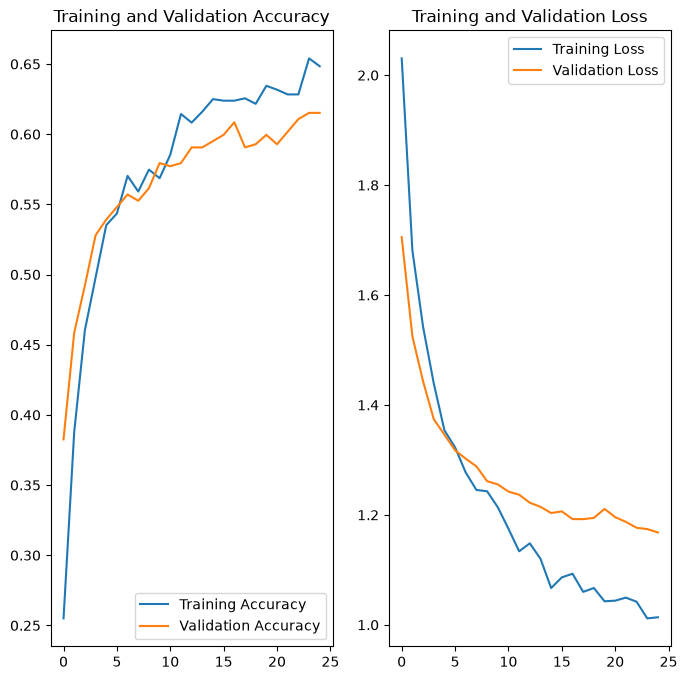

In [17]:
acc = history_frozen.history['accuracy']
val_acc = history_frozen.history['val_accuracy']

loss = history_frozen.history['loss']
val_loss = history_frozen.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


**결과**: best val accuracy 0.615 (최종 epoch도 0.615)로 베이스라인(0.557) 대비 상승했고, epoch 간 변동도 작아졌다.

**결론**: 동결 상태에서도 사전학습 특징이 유효하다. 특징추출기 자체를 피부 병변 도메인에 적응시키면 추가 상승 여지가 있다 → fine-tuning.

## 4. Fine-tuning — 상위 블록만 해제

**가설**: ImageNet 특징은 일반 물체 위주이므로, 백본 상위 블록을 낮은 학습률로 재학습하면 병변 특유의 패턴(색소 분포, 경계 불규칙성)에 적응해 성능이 더 오를 것이다.

**실험 설계**
- `base_model.trainable = True` 후 **`block6a` 이전 층은 다시 동결** — 하위층의 범용 특징(에지·질감)은 보존한다
- `BatchNormalization` 층은 전부 동결 유지 — 작은 배치에서 BN 통계가 흔들리면 학습이 붕괴한다
- 학습률 1e-5로 재컴파일 — 사전학습 가중치를 천천히 갱신
- `EarlyStopping(patience=5, restore_best_weights=True)` + `ReduceLROnPlateau`로 과적합 시점에서 자동 중단

In [18]:
# Fine-tuning: 상위 블록만 학습 대상으로 해제
base_model.trainable = True

fine_tune_from = 'block6a'  # 이 블록부터 학습 허용
unfreeze = False
for layer in base_model.layers:
    if layer.name.startswith(fine_tune_from):
        unfreeze = True
    if not unfreeze:
        layer.trainable = False
    # BatchNorm은 항상 동결 (이동평균 통계 보호)
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"base_model 학습 가능 층: {trainable_count} / {len(base_model.layers)}")

# 낮은 학습률로 재컴파일 (사전학습 가중치 보호)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

base_model 학습 가능 층: 59 / 238


In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
)

Epoch 1/30


 1/56 ━━━━━━━━━━━━━━━━━━━━ 6:06 7s/step - accuracy: 0.5938 - loss: 0.9370

 2/56 ━━━━━━━━━━━━━━━━━━━━ 22s 421ms/step - accuracy: 0.5938 - loss: 0.9904

 3/56 ━━━━━━━━━━━━━━━━━━━━ 21s 413ms/step - accuracy: 0.5729 - loss: 1.0213

 4/56 ━━━━━━━━━━━━━━━━━━━━ 21s 410ms/step - accuracy: 0.6016 - loss: 1.0145

...

54/56 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.7685 - loss: 0.6560

55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.7670 - loss: 0.6558

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.7684 - loss: 0.6560

56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 449ms/step - accuracy: 0.7684 - loss: 0.6560 - val_accuracy: 0.6376 - val_loss: 1.0607 - learning_rate: 1.2500e-06


Restoring model weights from the end of the best epoch: 29.


동결 단계 best val_accuracy      : 0.6152
Fine-tuning best val_accuracy    : 0.6465
개선폭                           : +0.0313


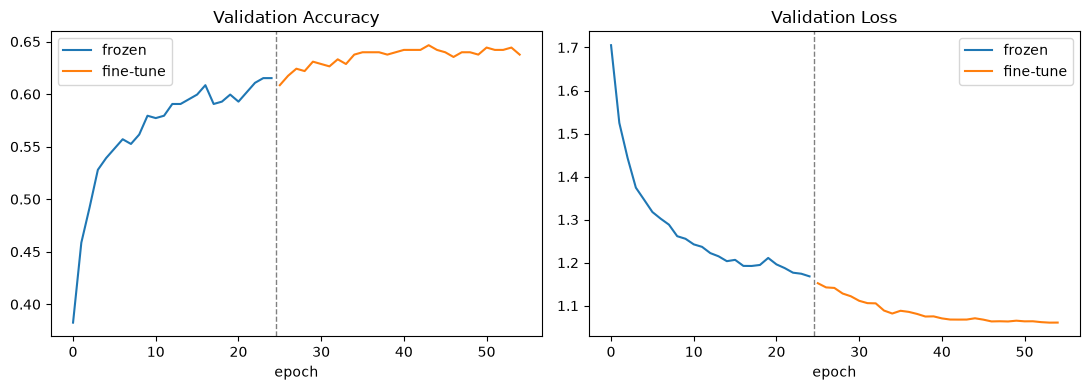

In [20]:
# 동결(feature extraction) vs fine-tuning 성능 비교
best_frozen = max(history_frozen.history['val_accuracy'])
best_finetune = max(history_finetune.history['val_accuracy'])
print(f"동결 단계 best val_accuracy      : {best_frozen:.4f}")
print(f"Fine-tuning best val_accuracy    : {best_finetune:.4f}")
print(f"개선폭                           : {best_finetune - best_frozen:+.4f}")

offset = len(history_frozen.history['val_accuracy'])
ft_range = range(offset, offset + len(history_finetune.history['val_accuracy']))

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history_frozen.history['val_accuracy'], label='frozen')
plt.plot(ft_range, history_finetune.history['val_accuracy'], label='fine-tune')
plt.axvline(offset - 0.5, color='gray', linestyle='--', linewidth=1)
plt.title('Validation Accuracy')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_frozen.history['val_loss'], label='frozen')
plt.plot(ft_range, history_finetune.history['val_loss'], label='fine-tune')
plt.axvline(offset - 0.5, color='gray', linestyle='--', linewidth=1)
plt.title('Validation Loss')
plt.xlabel('epoch')
plt.legend()

plt.tight_layout()
plt.show()

**결과**: fine-tuning best val accuracy **0.647** — 동결(0.615) 대비 **+3.1%p**. 30 epochs 동안 EarlyStopping 미발동(과적합 신호 없이 완주), `restore_best_weights`로 최적 가중치 복원.

**결론**: 상위 블록의 도메인 적응이 유효했다. 다음 단계인 hold-out Test 셋으로 일반화 성능을 확정한다.

## 5. Test 셋 최종 평가

**목적**: validation 셋은 모델 선택 과정에 이미 사용됐으므로, 학습에 한 번도 쓰지 않은 Test 118장으로 일반화 성능을 확정한다.

**실험**: `data_dir_test`를 로드해 최종(fine-tuned) 모델로 평가 — 전체 accuracy, 클래스별 precision/recall/F1(`classification_report`), 혼동행렬 heatmap.

In [21]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_test,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,  # 예측-라벨 순서 유지
)
test_class_names = test_ds.class_names

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f} / Test loss: {test_loss:.4f}\n")

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=test_class_names, zero_division=0))

Found 118 files belonging to 9 classes.


Test accuracy: 0.5424 / Test loss: 1.4954



                            precision    recall  f1-score   support

         actinic keratosis       0.60      0.19      0.29        16
      basal cell carcinoma       0.55      0.75      0.63        16
            dermatofibroma       1.00      0.56      0.72        16
                  melanoma       0.50      0.25      0.33        16
                     nevus       0.45      0.94      0.61        16
pigmented benign keratosis       0.44      0.69      0.54        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.54      0.44      0.48        16
           vascular lesion       1.00      1.00      1.00         3

                  accuracy                           0.54       118
                 macro avg       0.56      0.53      0.51       118
              weighted avg       0.58      0.54      0.51       118



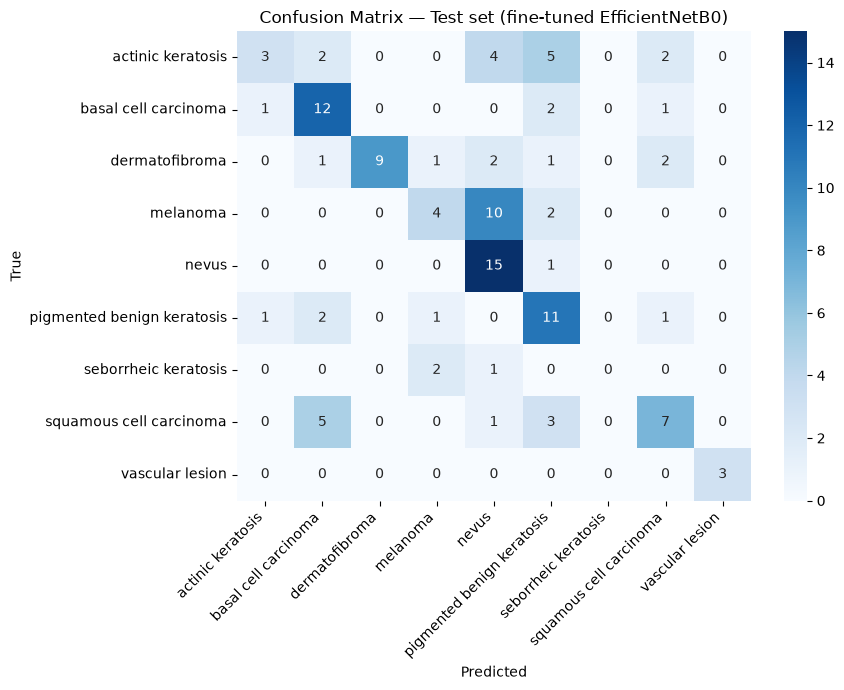

In [22]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_class_names, yticklabels=test_class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Test set (fine-tuned EfficientNetB0)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. 한계와 다음 단계

**한계**
- Test 셋이 118장뿐이라 클래스별 지표(특히 소수 클래스)의 신뢰구간이 넓다.
- 클래스 불균형을 손실 가중치나 리샘플링으로 보정하지 않았다.
- 데이터 증강을 최종 파이프라인에 적용하지 않았다 — 과적합 완화 여지가 남아 있다.
- 단일 시드·단일 분할 결과라 성능의 재현 분산을 측정하지 못했다.

**다음 단계**
1. `tf.keras.layers.RandomFlip/RandomRotation/RandomZoom`을 **train 파이프라인에만** 추가해 재실험
2. `class_weight`를 적용해 소수 클래스 recall 변화 확인
3. EfficientNetB1~B3 등 더 큰 백본과 입력 해상도(224²) 비교
4. Grad-CAM으로 오분류 사례의 주목 영역 분석